# 10 · Discounted cash flow valuation from SEC data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/10_dcf_valuation.ipynb)

**What you will learn**

- How to assemble DCF inputs from filings: annual free cash flow, cash, debt and diluted shares.
- How a two-stage DCF turns those inputs and your assumptions into a value per share.
- How sensitive that value is to the discount rate and terminal growth, and what growth the
  current share price implies (a reverse DCF).

**Plan required:** none (free sample tier). The sample holds the last five fiscal years; a paid
plan gives a longer cash-flow history with the same code.

Valuein publishes the reported inputs, not an intrinsic value: a DCF is only as good as its
assumptions, and those are yours. The assumptions below are placeholders to change.

In [1]:
%pip install -q valuein-sdk matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Annual cash flows

Free cash flow (FCF) = operating cash flow minus capital expenditure. Two data rules:

- Annual values come from `fiscal_period = 'FY'` rows, `numeric_value`. (On an FY row
  `derived_quarterly_value` is the implied fourth quarter, not the year.)
- The sign of `CAPEX` varies by filer, so take its absolute value.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from valuein_sdk import ValueinClient

TICKER = "MSFT"
client = ValueinClient()
cik = client.resolve(TICKER)["cik"].iloc[0]


def annual(concepts: list[str]) -> pd.DataFrame:
    """Latest-vintage annual values, one row per fiscal year end, one column per concept."""
    names = ", ".join(f"'{c}'" for c in concepts)
    long = client.run_query(f"""
        SELECT period_end, standard_concept, numeric_value
        FROM fact
        WHERE entity_id = '{cik}' AND standard_concept IN ({names}) AND fiscal_period = 'FY'
          AND (period_span_days BETWEEN 350 AND 380 OR period_start IS NULL)
        QUALIFY ROW_NUMBER() OVER (PARTITION BY standard_concept, period_end ORDER BY accepted_at DESC, priority DESC) = 1
    """)
    return long.pivot(index="period_end", columns="standard_concept", values="numeric_value").sort_index()


flows = annual(["TotalRevenue", "OperatingCashFlow", "CAPEX"])
flows["FCF"] = flows["OperatingCashFlow"] - flows["CAPEX"].abs()
flows["FCF_margin"] = flows["FCF"] / flows["TotalRevenue"]

shown = flows.copy()
for column in ["TotalRevenue", "OperatingCashFlow", "CAPEX", "FCF"]:
    shown[column] = shown[column] / 1e9  # USD billions
shown.round(3)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


standard_concept,CAPEX,OperatingCashFlow,TotalRevenue,FCF,FCF_margin
period_end,,,,,
2021-06-30,20.622,76.740,168.088,56.118,0.334
2022-06-30,23.886,89.035,198.270,65.149,0.329
2023-06-30,28.107,87.582,211.915,59.475,0.281
2024-06-30,44.477,118.548,245.122,74.071,0.302
2025-06-30,64.551,136.162,281.724,71.611,0.254
2026-06-30,115.948,182.935,331.839,66.987,0.202


## 2. Balance sheet and share count

Equity value = enterprise value + cash - debt. Use the latest fiscal year end, and diluted
weighted shares to get a per-share value comparable to the share price. Debt is reported under
different concepts by different companies, so take the first one available.

In [3]:
balance = annual(["CashAndEquivalents", "TotalDebt", "LongTermDebtTotal", "LongTermDebt",
                  "ShortTermDebt", "WeightedAvgSharesDiluted"])
latest = balance.iloc[-1]
debt = next(latest[c] for c in ["TotalDebt", "LongTermDebtTotal", "LongTermDebt"]
            if c in latest and pd.notna(latest[c]))
cash = latest["CashAndEquivalents"]
shares = latest["WeightedAvgSharesDiluted"]
price = client.stock_price(TICKER)
print(f"fiscal year end : {balance.index[-1]:%Y-%m-%d}")
print(f"cash            : {cash / 1e9:,.1f} bn")
print(f"debt            : {debt / 1e9:,.1f} bn")
print(f"diluted shares  : {shares / 1e9:,.3f} bn")
print(f"share price     : {price['close'].iloc[0]:,.2f} on {price['price_date'].iloc[0]:%Y-%m-%d}")

fiscal year end : 2026-06-30
cash            : 20.9 bn
debt            : 40.3 bn
diluted shares  : 7.453 bn
share price     : 512.90 on 2026-09-30


## 3. Your assumptions

A two-stage model: FCF grows at `growth` for `years`, then at `terminal_growth` forever. The
starting growth rate here is the historical FCF growth, capped; replace any of these with your
own view.

In [4]:
fcf_now = flows["FCF"].iloc[-1]
years_of_history = (flows.index[-1] - flows.index[0]).days / 365.25
historical_growth = (flows["FCF"].iloc[-1] / flows["FCF"].iloc[0]) ** (1 / years_of_history) - 1

ASSUMPTIONS = {
    "growth": float(np.clip(historical_growth, 0.0, 0.15)),  # stage-1 annual FCF growth
    "years": 5,                                               # length of stage 1
    "discount_rate": 0.09,                                    # your required return
    "terminal_growth": 0.025,                                 # long-run growth after stage 1
}
print(f"historical FCF growth: {historical_growth:.1%} per year over {years_of_history:.1f} years")
ASSUMPTIONS

historical FCF growth: 3.6% per year over 5.0 years


{'growth': 0.03604775529019322,
 'years': 5,
 'discount_rate': 0.09,
 'terminal_growth': 0.025}

In [5]:
def value_per_share(fcf: float, growth: float, years: int, discount_rate: float,
                    terminal_growth: float) -> float:
    """Two-stage DCF equity value per share."""
    flows_1 = [fcf * (1 + growth) ** t for t in range(1, years + 1)]
    pv_stage_1 = sum(f / (1 + discount_rate) ** t for t, f in enumerate(flows_1, start=1))
    terminal = flows_1[-1] * (1 + terminal_growth) / (discount_rate - terminal_growth)
    pv_terminal = terminal / (1 + discount_rate) ** years
    equity = pv_stage_1 + pv_terminal + cash - debt
    return equity / shares


base = value_per_share(fcf_now, **ASSUMPTIONS)
print(f"value per share : {base:,.2f}")
print(f"share price     : {price['close'].iloc[0]:,.2f}")

value per share : 146.05
share price     : 512.90


## 4. Sensitivity

The terminal value is usually most of a DCF, so the result swings with the two rates that
drive it. Look at the whole grid before quoting one number.

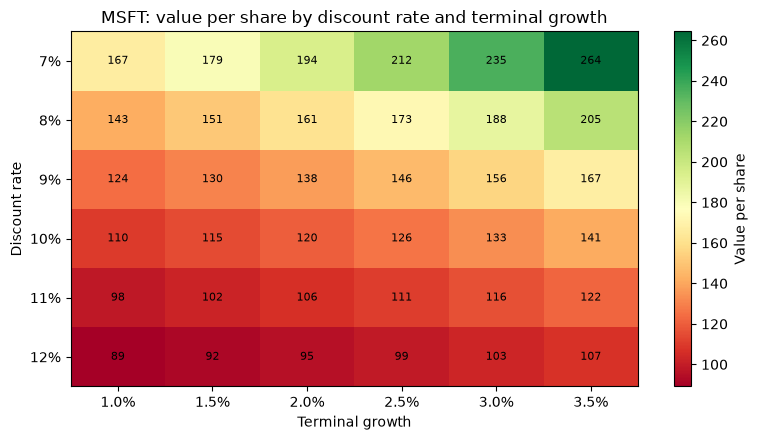

In [6]:
rates = np.arange(0.07, 0.121, 0.01)
terminal_rates = np.arange(0.01, 0.0351, 0.005)
grid = pd.DataFrame(
    [[value_per_share(fcf_now, ASSUMPTIONS["growth"], ASSUMPTIONS["years"], r, g) for g in terminal_rates]
     for r in rates],
    index=[f"{r:.0%}" for r in rates], columns=[f"{g:.1%}" for g in terminal_rates],
)
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(grid.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(grid.columns)), grid.columns)
ax.set_yticks(range(len(grid.index)), grid.index)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid.values[i, j]:,.0f}", ha="center", va="center", fontsize=8)
ax.set_xlabel("Terminal growth")
ax.set_ylabel("Discount rate")
ax.set_title(f"{TICKER}: value per share by discount rate and terminal growth")
fig.colorbar(image, ax=ax, label="Value per share")
plt.tight_layout()
plt.show()

## 5. Reverse DCF: what growth does the price imply?

Instead of asking what the company is worth, ask what stage-1 growth makes the DCF equal to
today's price, keeping the other assumptions. Compare it with the historical growth above.

In [7]:
def implied_growth(target_price: float, low: float = -0.5, high: float = 1.0) -> float:
    """Stage-1 growth that makes the DCF value equal `target_price` (bisection)."""
    for _ in range(100):
        mid = (low + high) / 2
        value = value_per_share(fcf_now, mid, ASSUMPTIONS["years"], ASSUMPTIONS["discount_rate"],
                                ASSUMPTIONS["terminal_growth"])
        low, high = (mid, high) if value < target_price else (low, mid)
    return (low + high) / 2


print(f"growth implied by the price : {implied_growth(price['close'].iloc[0]):.1%} per year")
print(f"historical FCF growth       : {historical_growth:.1%} per year")

growth implied by the price : 35.7% per year
historical FCF growth       : 3.6% per year


In [8]:
client.close()

## Next steps

- The Valuein MCP server runs a DCF server-side with your parameters (`compute_dcf`) and can
  export it to Excel (`generate_dcf_xlsx`; from Python, `client.generate_dcf_xlsx(ticker)` on
  Pro and above).
- **[11 · Piotroski F-score screen](11_piotroski_screen.ipynb)**.
- Script version: [`python/dcf_inputs.py`](../python/dcf_inputs.py).